# Model has only BME loss and trained regressive transformer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive_bce/lightning_logs/version_3/metrics.csv"
metrics = pd.read_csv(file_path)

print(metrics.isnull().sum())  # Count missing values in each column
metrics = metrics.fillna(method='ffill')  # Forward fill missing values



epoch                              7839
train_loss_step                    8241
train_accuracy_step                8241
train_precision_step               8241
step                                  0
                                  ...  
train_recall/user_9               16044
train_optimal_threshold/user_9    16044
train_best_f1/user_9              16044
train_precision/user_9            16044
train_loss/user_9                 16044
Length: 156, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_23064\3152356157.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  metrics = metrics.fillna(method='ffill')  # Forward fill missing values


In [3]:
# Check if required columns exist
required_columns = {'epoch', 'train_loss_epoch', 'val_loss'}
if required_columns.issubset(metrics.columns):
    # Filter the DataFrame for the required columns
    filtered_df = metrics[['epoch', 'train_loss_epoch', 'val_loss']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_loss = filtered_df.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch', 'train_loss_epoch', and 'val_loss':\n", distinct_epochs_and_loss)
else:
    print("One or more required columns are missing from the DataFrame.")

Distinct values of 'epoch', 'train_loss_epoch', and 'val_loss':
        epoch  train_loss_epoch  val_loss
79       0.0          1.093206  1.073611
81       1.0          1.093206  1.073611
158      1.0          1.093206  1.061396
159      1.0          1.072067  1.061396
161      2.0          1.072067  1.061396
...      ...               ...       ...
15998  199.0          0.538037  1.098245
15999  199.0          0.532312  1.098245
16001  200.0          0.532312  1.098245
16078  200.0          0.532312  1.080530
16079  200.0          0.541370  1.080530

[601 rows x 3 columns]


# Loss for train and validation 

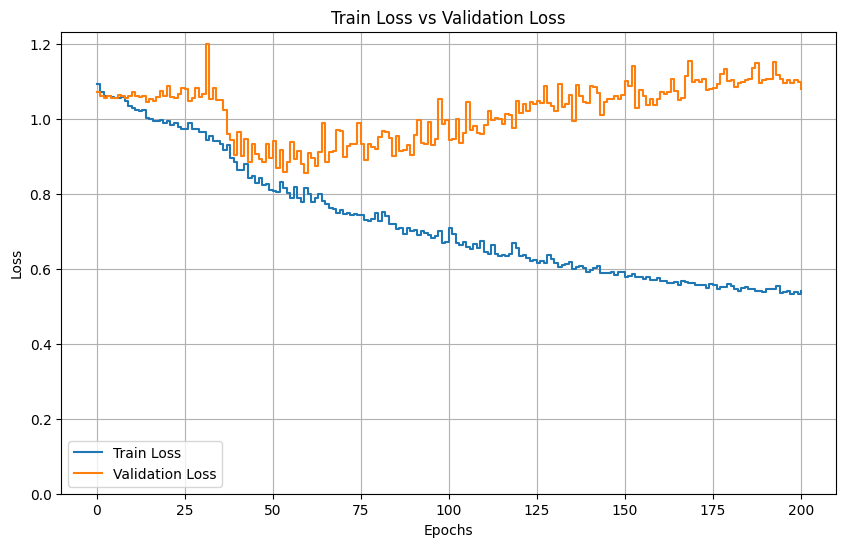

In [4]:
import matplotlib.pyplot as plt

# Assuming distinct_epochs_and_loss is your DataFrame containing 'epoch', 'train_loss_epoch', and 'val_loss'
plt.figure(figsize=(10, 6))

# Plot Train Loss
plt.plot(distinct_epochs_and_loss['epoch'], distinct_epochs_and_loss['train_loss_epoch'], label='Train Loss', linestyle='-', marker=None)

# Plot Validation Loss
plt.plot(distinct_epochs_and_loss['epoch'], distinct_epochs_and_loss['val_loss'], label='Validation Loss', linestyle='-', marker=None)

# Set plot labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Validation Loss')
plt.legend()
plt.grid(True)
plt.ylim(0)  # Start y-axis from 0

# Show the plot
plt.show()


# Loss for each users val and train

C:\Users\Admin\AppData\Local\Temp\ipykernel_23064\479564233.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_users).colors


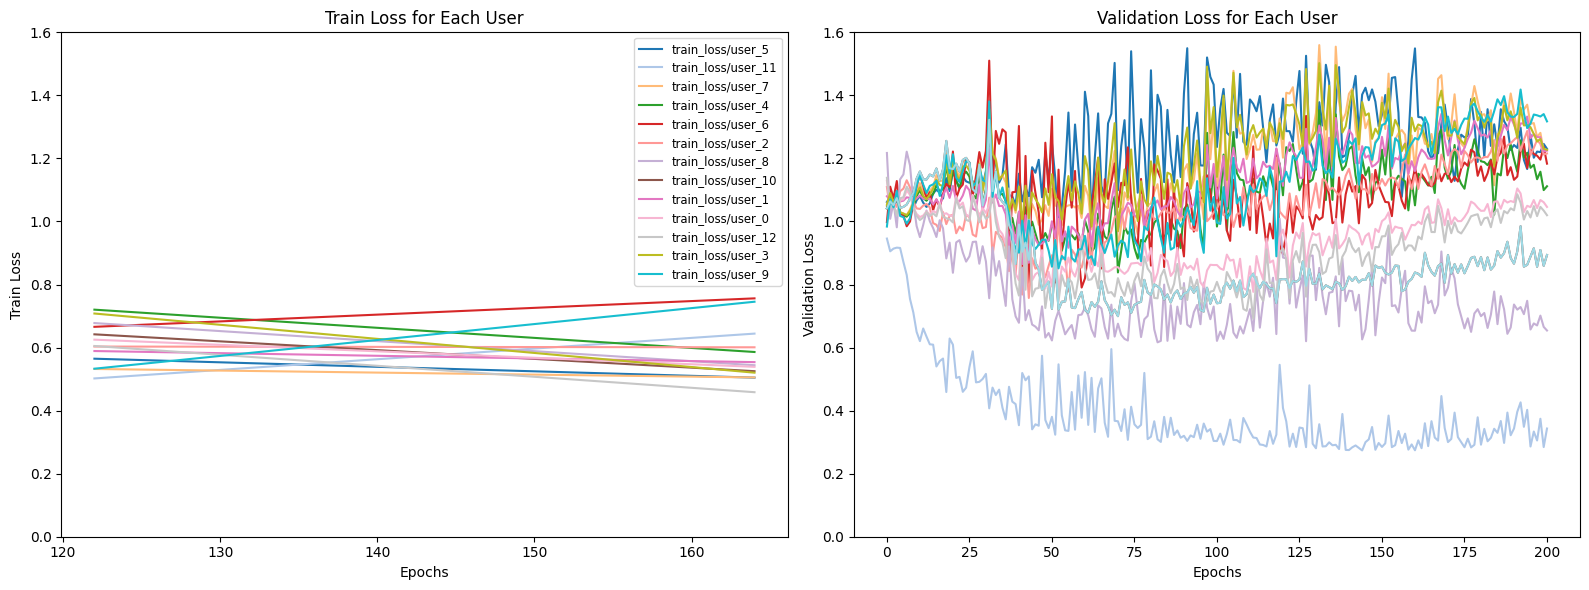

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load the CSV file
metrics_data = pd.read_csv("D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive_bce/lightning_logs/version_3/metrics.csv")

# Extract user-specific train loss columns and validation loss columns
train_loss_columns = [col for col in metrics_data.columns if col.startswith('train_loss/user_')]
val_loss_columns = [col for col in metrics_data.columns if col.startswith('val_loss/user_')]

# Drop NaN values
train_loss_data = metrics_data[['epoch'] + train_loss_columns].dropna()
val_loss_data = metrics_data[['epoch'] + val_loss_columns].dropna()

# Generate unique colors for each user
num_users = max(len(train_loss_columns), len(val_loss_columns))
colors = cm.get_cmap('tab20', num_users).colors

# Create subplots WITHOUT shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Removed sharey=True

# Set separate y-axis limits
axes[0].set_ylim(0, 1.6)   # Train loss range
axes[1].set_ylim(0, 1.6)  # Validation loss range

# Plot train loss with unique colors
for i, col in enumerate(train_loss_columns):
    axes[0].plot(train_loss_data['epoch'], train_loss_data[col], label=col, color=colors[i])
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Train Loss")
axes[0].set_title("Train Loss for Each User")
axes[0].legend(loc="upper right", fontsize='small')

# Plot validation loss with unique colors
for i, col in enumerate(val_loss_columns):
    axes[1].plot(val_loss_data['epoch'], val_loss_data[col], label=col, color=colors[i])
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Validation Loss")
axes[1].set_title("Validation Loss for Each User")

# Adjust layout for better visualization
plt.tight_layout()
plt.show()


# Precision and accuracy for train and validation

In [6]:
# Check if required columns exist
required_columns = {'epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy'}
if required_columns.issubset(metrics.columns):
    # Filter the DataFrame for the required columns
    filtered_df = metrics[['epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_precision = filtered_df.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy':\n", distinct_epochs_and_precision)
else:
    print("One or more required columns are missing from the DataFrame.")

Distinct values of 'epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy':
        epoch  train_precision_epoch  val_precision  train_accuracy_epoch  \
79       0.0               0.419162       0.471760              0.427237   
81       1.0               0.419162       0.471760              0.427237   
158      1.0               0.419162       0.470529              0.427237   
159      1.0               0.419262       0.470529              0.424803   
161      2.0               0.419262       0.470529              0.424803   
...      ...                    ...            ...                   ...   
15998  199.0               0.763438       0.573124              0.849205   
15999  199.0               0.774058       0.573124              0.850068   
16001  200.0               0.774058       0.573124              0.850068   
16078  200.0               0.774058       0.579051              0.850068   
16079  200.0               0.777542       0.579051   

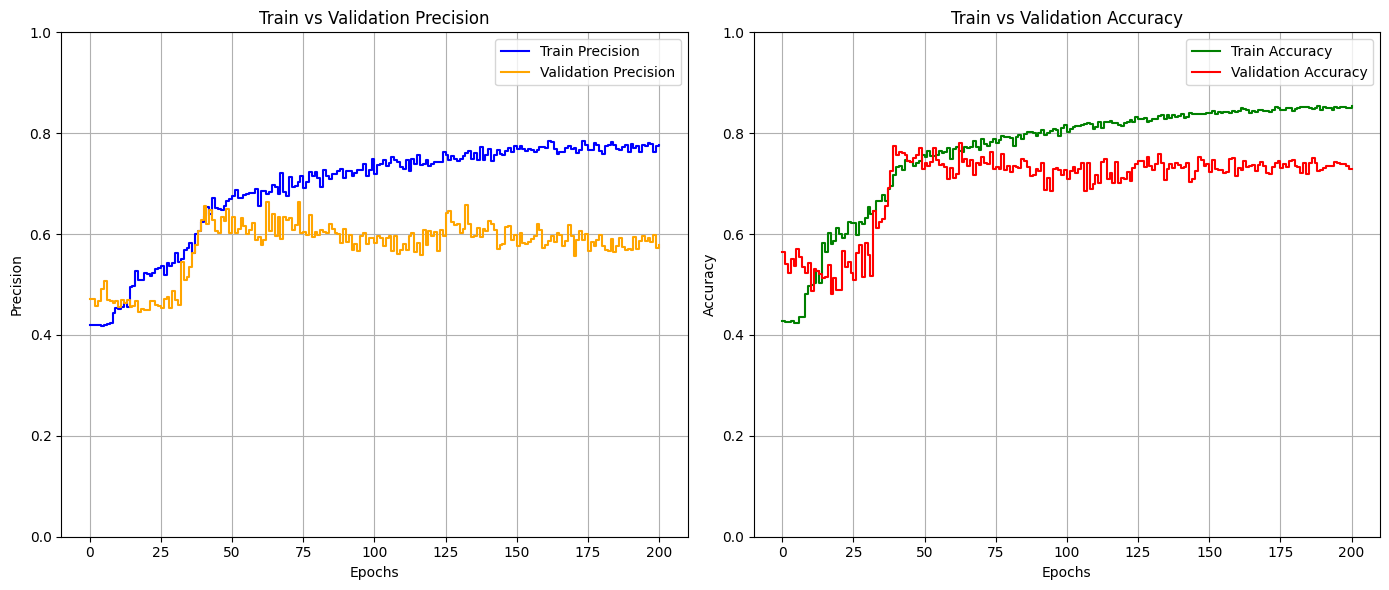

In [7]:
import matplotlib.pyplot as plt

# Check if required columns exist in DataFrame
required_columns = {'epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy'}
if required_columns.issubset(metrics.columns):
    # Filter and clean the DataFrame
    filtered_df = metrics[['epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy']].dropna()
    
    # Get distinct (unique) rows
    distinct_epochs_and_metrics = filtered_df.drop_duplicates()
    
    # Create subplots: One for Precision, One for Accuracy
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Two subplots (1 row, 2 columns)

    # ---- Subplot 1: Train & Validation Precision ----
    axes[0].plot(distinct_epochs_and_metrics['epoch'], distinct_epochs_and_metrics['train_precision_epoch'], 
                 label='Train Precision', linestyle='-', marker=None, color='blue')

    axes[0].plot(distinct_epochs_and_metrics['epoch'], distinct_epochs_and_metrics['val_precision'], 
                 label='Validation Precision', linestyle='-', marker=None, color='orange')

    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Precision')
    axes[0].set_title('Train vs Validation Precision')
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_ylim(0, 1)  # Precision typically ranges from 0 to 1

    # ---- Subplot 2: Train & Validation Accuracy ----
    axes[1].plot(distinct_epochs_and_metrics['epoch'], distinct_epochs_and_metrics['train_accuracy_epoch'], 
                 label='Train Accuracy', linestyle='-', marker=None, color='green')

    axes[1].plot(distinct_epochs_and_metrics['epoch'], distinct_epochs_and_metrics['val_accuracy'], 
                 label='Validation Accuracy', linestyle='-', marker=None, color='red')

    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Train vs Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_ylim(0, 1)  # Accuracy typically ranges from 0 to 1

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

else:
    print("One or more required columns are missing from the DataFrame.")


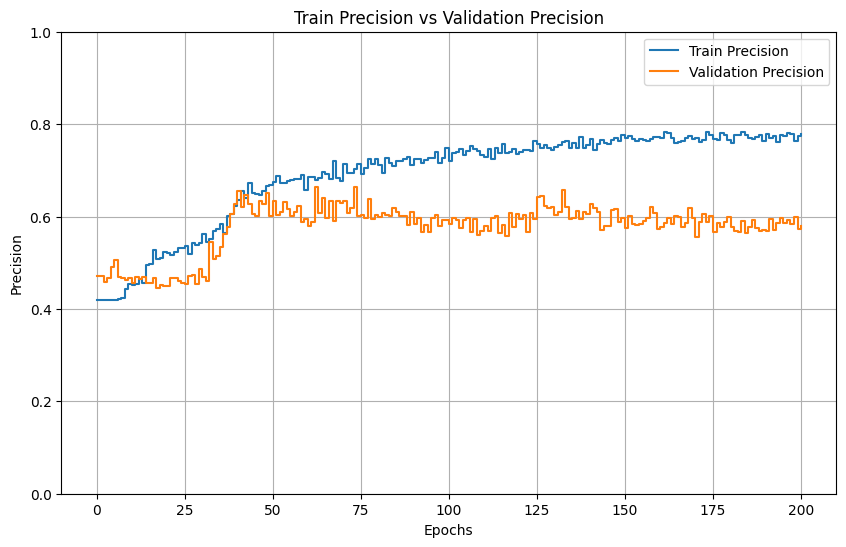

In [8]:
import matplotlib.pyplot as plt

# Assuming distinct_epochs_and_loss is your DataFrame containing 'epoch', 'train_precision_epoch', and 'val_precision'
plt.figure(figsize=(10, 6))

# Plot Train Loss
plt.plot(distinct_epochs_and_precision['epoch'], distinct_epochs_and_precision['train_precision_epoch'], label='Train Precision', linestyle='-', marker=None)

# Plot Validation Loss
plt.plot(distinct_epochs_and_precision['epoch'], distinct_epochs_and_precision['val_precision'], label='Validation Precision', linestyle='-', marker=None)

# Set plot labels and title
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Train Precision vs Validation Precision')
plt.legend()
plt.grid(True)
plt.ylim(0,1)  # Start y-axis from 0


# Show the plot
plt.show()


In [9]:
# Check if required columns exist
required_columns = {'epoch', 'train_accuracy_epoch', 'val_accuracy'}
if required_columns.issubset(metrics.columns):
    # Filter the DataFrame for the required columns
    filtered_df = metrics[['epoch', 'train_accuracy_epoch', 'val_accuracy']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_accuracy = filtered_df.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch', 'train_accuracy_epoch', and 'val_accuracy':\n", distinct_epochs_and_accuracy)
else:
    print("One or more required columns are missing from the DataFrame.")

Distinct values of 'epoch', 'train_accuracy_epoch', and 'val_accuracy':
        epoch  train_accuracy_epoch  val_accuracy
79       0.0              0.427237      0.565039
81       1.0              0.427237      0.565039
158      1.0              0.427237      0.540838
159      1.0              0.424803      0.540838
161      2.0              0.424803      0.540838
...      ...                   ...           ...
15998  199.0              0.849205      0.729365
15999  199.0              0.850068      0.729365
16001  200.0              0.850068      0.729365
16078  200.0              0.850068      0.729365
16079  200.0              0.853735      0.729365

[601 rows x 3 columns]


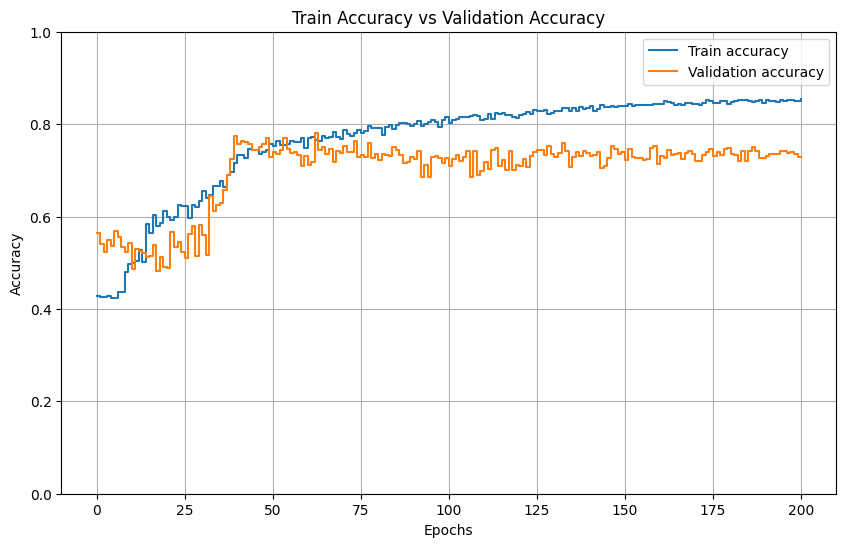

In [12]:
import matplotlib.pyplot as plt

# Assuming distinct_epochs_and_accuracy is your DataFrame containing 'epoch', 'train_accuracy_epoch', and 'val_accuracy'
plt.figure(figsize=(10, 6))

# Plot Train Accuracy
plt.plot(distinct_epochs_and_accuracy['epoch'], distinct_epochs_and_accuracy['train_accuracy_epoch'], label='Train accuracy', linestyle='-', marker=None)

# Plot Validation Accuracy
plt.plot(distinct_epochs_and_accuracy['epoch'], distinct_epochs_and_accuracy['val_accuracy'], label='Validation accuracy', linestyle='-', marker=None)

# Set plot labels and title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train Accuracy vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0,1)  # Start y-axis from 0

# Show the plot
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_23064\1602965461.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_users).colors


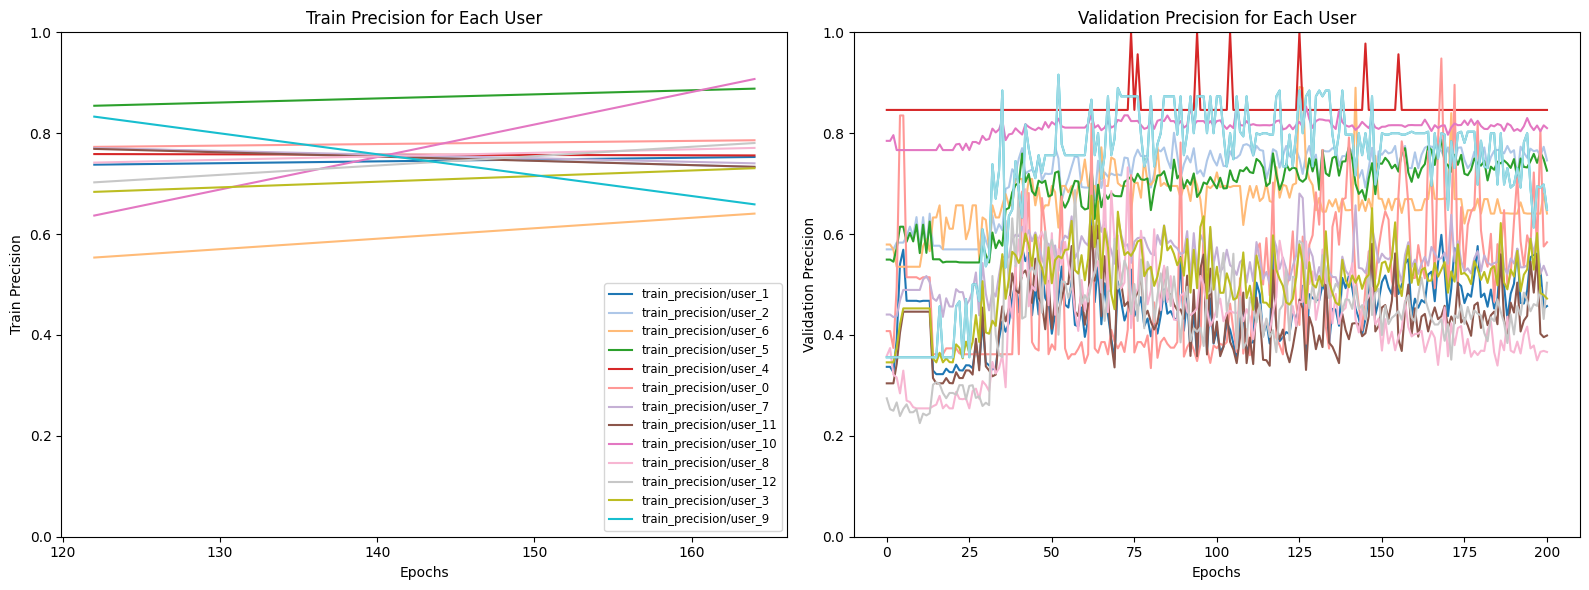

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load the CSV file
metrics_data = pd.read_csv("D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive_bce/lightning_logs/version_3/metrics.csv")

# Extract user-specific train loss columns and validation loss columns
train_precision_columns = [col for col in metrics_data.columns if col.startswith('train_precision/user_')]
val_precision_columns = [col for col in metrics_data.columns if col.startswith('val_precision/user_')]

# Drop NaN values
train_precision_data = metrics_data[['epoch'] + train_precision_columns].dropna()
val_precision_data = metrics_data[['epoch'] + val_precision_columns].dropna()

# Generate unique colors for each user
num_users = max(len(train_precision_columns), len(val_precision_columns))
colors = cm.get_cmap('tab20', num_users).colors

# Create subplots WITHOUT shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Removed sharey=True

# Set separate y-axis limits
axes[0].set_ylim(0, 1)   # Train precision range
axes[1].set_ylim(0, 1)  # Validation precision range

# Plot train loss with unique colors
for i, col in enumerate(train_precision_columns):
    axes[0].plot(train_precision_data['epoch'], train_precision_data[col], label=col, color=colors[i])
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Train Precision")
axes[0].set_title("Train Precision for Each User")
axes[0].legend(loc="lower right", fontsize='small')

# Plot validation loss with unique colors
for i, col in enumerate(val_precision_columns):
    axes[1].plot(val_precision_data['epoch'], val_precision_data[col], label=col, color=colors[i])
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Validation Precision")
axes[1].set_title("Validation Precision for Each User")

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
